In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
# Cell 1: Import all required libraries
import numpy as np
import pandas as pd
import librosa
import librosa.display
import soundfile as sf
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

# Scikit-learn
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Statistical process control
from statsmodels.stats.diagnostic import recursive_olsresiduals
from scipy import stats

# Audio processing
import IPython.display as ipd

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Librosa version: {librosa.__version__}")

Libraries imported successfully!
TensorFlow version: 2.17.0
Librosa version: 0.10.2.post1


In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
# Cell 2: Data exploration and path setup
# Define the data path
data_path = "data/Fadi_Karkafi"

# Check if path exists
if not os.path.exists(data_path):
    # Try alternative paths
    alternative_paths = [
        "/content/drive/MyDrive/Fadi_Karkafi",
        "./Fadi_Karkafi",
        "./data"
    ]
    
    for alt_path in alternative_paths:
        if os.path.exists(alt_path):
            data_path = alt_path
            print(f"Found data at: {data_path}")
            break
    else:
        raise FileNotFoundError(f"Data directory not found. Please check the path: {data_path}")
else:
    print(f"Data directory found: {data_path}")

# Find all audio files
audio_extensions = ['.wav', '.mp3', '.flac', '.aiff', '.ogg', '.m4a', '.WAV', '.MP3']
audio_files = []

print("\nSearching for audio files...")
for root, dirs, files in os.walk(data_path):
    for file in files:
        if any(file.lower().endswith(ext) for ext in audio_extensions):
            full_path = os.path.join(root, file)
            audio_files.append(full_path)

print(f"Total audio files found: {len(audio_files)}")

if audio_files:
    # Display first 10 files
    print("\nFirst 10 audio files:")
    for i, file in enumerate(audio_files[:10]):
        print(f"{i+1:2d}. {os.path.basename(file)}")
        print(f"    Path: {file}")
    
    # Check file sizes
    print("\nFile sizes:")
    for i, file in enumerate(audio_files[:5]):
        size_mb = os.path.getsize(file) / (1024 * 1024)
        print(f"{os.path.basename(file)}: {size_mb:.2f} MB")
else:
    print("No audio files found! Please check the data directory.")

Data directory found: data/Fadi_Karkafi

Searching for audio files...
Total audio files found: 30

First 10 audio files:
 1. normal_id_04_00000533.wav
    Path: data/Fadi_Karkafi/normal_id_04_00000533.wav
 2. normal_id_06_00000064.wav
    Path: data/Fadi_Karkafi/normal_id_06_00000064.wav
 3. normal_id_06_00000894.wav
    Path: data/Fadi_Karkafi/normal_id_06_00000894.wav
 4. normal_id_06_00000896.wav
    Path: data/Fadi_Karkafi/normal_id_06_00000896.wav
 5. normal_id_04_00000848.wav
    Path: data/Fadi_Karkafi/normal_id_04_00000848.wav
 6. normal_id_06_00000909.wav
    Path: data/Fadi_Karkafi/normal_id_06_00000909.wav
 7. normal_id_06_00000016.wav
    Path: data/Fadi_Karkafi/normal_id_06_00000016.wav
 8. normal_id_04_00000446.wav
    Path: data/Fadi_Karkafi/normal_id_04_00000446.wav
 9. normal_id_06_00000883.wav
    Path: data/Fadi_Karkafi/normal_id_06_00000883.wav
10. normal_id_04_00000863.wav
    Path: data/Fadi_Karkafi/normal_id_04_00000863.wav

File sizes:
normal_id_04_00000533.wav:

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# Cell 3: Audio loading and basic analysis functions
def load_audio_with_info(file_path, target_sr=22050, duration=None):
    """Load audio file and return basic information"""
    try:
        if duration:
            audio, sr = librosa.load(file_path, sr=target_sr, duration=duration)
        else:
            audio, sr = librosa.load(file_path, sr=target_sr)
        
        # Basic audio features
        duration_sec = len(audio) / sr
        rms = librosa.feature.rms(y=audio)[0].mean()
        zero_crossing = librosa.feature.zero_crossing_rate(audio)[0].mean()
        
        return {
            'audio': audio,
            'sr': sr,
            'duration': duration_sec,
            'rms': rms,
            'zero_crossing_rate': zero_crossing,
            'file_path': file_path,
            'file_name': os.path.basename(file_path)
        }
    except Exception as e:
        print(f"Error loading {file_path}: {str(e)}")
        return None

def analyze_audio_file(audio_data):
    """Perform detailed analysis on audio data"""
    audio = audio_data['audio']
    sr = audio_data['sr']
    
    # Spectral features
    spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean()
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0].mean()
    spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)[0].mean()
    
    # MFCCs
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    mfcc_mean = mfccs.mean(axis=1)
    
    # Chroma features
    chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
    chroma_mean = chroma.mean(axis=1)
    
    return {
        'spectral_centroid': spectral_centroid,
        'spectral_bandwidth': spectral_bandwidth,
        'spectral_rolloff': spectral_rolloff,
        'mfcc_mean': mfcc_mean,
        'chroma_mean': chroma_mean
    }

# Load and analyze first few files
print("Loading and analyzing sample audio files...")
sample_audio_data = []
analysis_results = []

for i, file_path in enumerate(tqdm(audio_files[:5], desc="Processing")):
    audio_data = load_audio_with_info(file_path, duration=10)  # Load only first 10 seconds
    if audio_data:
        sample_audio_data.append(audio_data)
        analysis = analyze_audio_file(audio_data)
        analysis_results.append(analysis)
        
        print(f"\nFile {i+1}: {audio_data['file_name']}")
        print(f"  Duration: {audio_data['duration']:.2f} seconds")
        print(f"  Sample rate: {audio_data['sr']} Hz")
        print(f"  RMS energy: {audio_data['rms']:.4f}")
        print(f"  Zero crossing rate: {audio_data['zero_crossing_rate']:.4f}")
        print(f"  Spectral centroid: {analysis['spectral_centroid']:.2f} Hz")

if sample_audio_data:
    print("\nPlaying first audio sample...")
    ipd.display(ipd.Audio(sample_audio_data[0]['audio'], rate=sample_audio_data[0]['sr']))

Loading and analyzing sample audio files...


Processing:  20%|██        | 1/5 [00:09<00:36,  9.20s/it]


File 1: normal_id_04_00000533.wav
  Duration: 10.00 seconds
  Sample rate: 22050 Hz
  RMS energy: 0.0109
  Zero crossing rate: 0.0823
  Spectral centroid: 1629.41 Hz


Processing:  60%|██████    | 3/5 [00:09<00:04,  2.21s/it]


File 2: normal_id_06_00000064.wav
  Duration: 10.00 seconds
  Sample rate: 22050 Hz
  RMS energy: 0.0111
  Zero crossing rate: 0.1524
  Spectral centroid: 2322.81 Hz

File 3: normal_id_06_00000894.wav
  Duration: 10.00 seconds
  Sample rate: 22050 Hz
  RMS energy: 0.0111
  Zero crossing rate: 0.0920
  Spectral centroid: 1735.04 Hz


Processing: 100%|██████████| 5/5 [00:09<00:00,  1.99s/it]


File 4: normal_id_06_00000896.wav
  Duration: 10.00 seconds
  Sample rate: 22050 Hz
  RMS energy: 0.0110
  Zero crossing rate: 0.0846
  Spectral centroid: 1671.83 Hz

File 5: normal_id_04_00000848.wav
  Duration: 10.00 seconds
  Sample rate: 22050 Hz
  RMS energy: 0.0109
  Zero crossing rate: 0.0841
  Spectral centroid: 1674.54 Hz

Playing first audio sample...


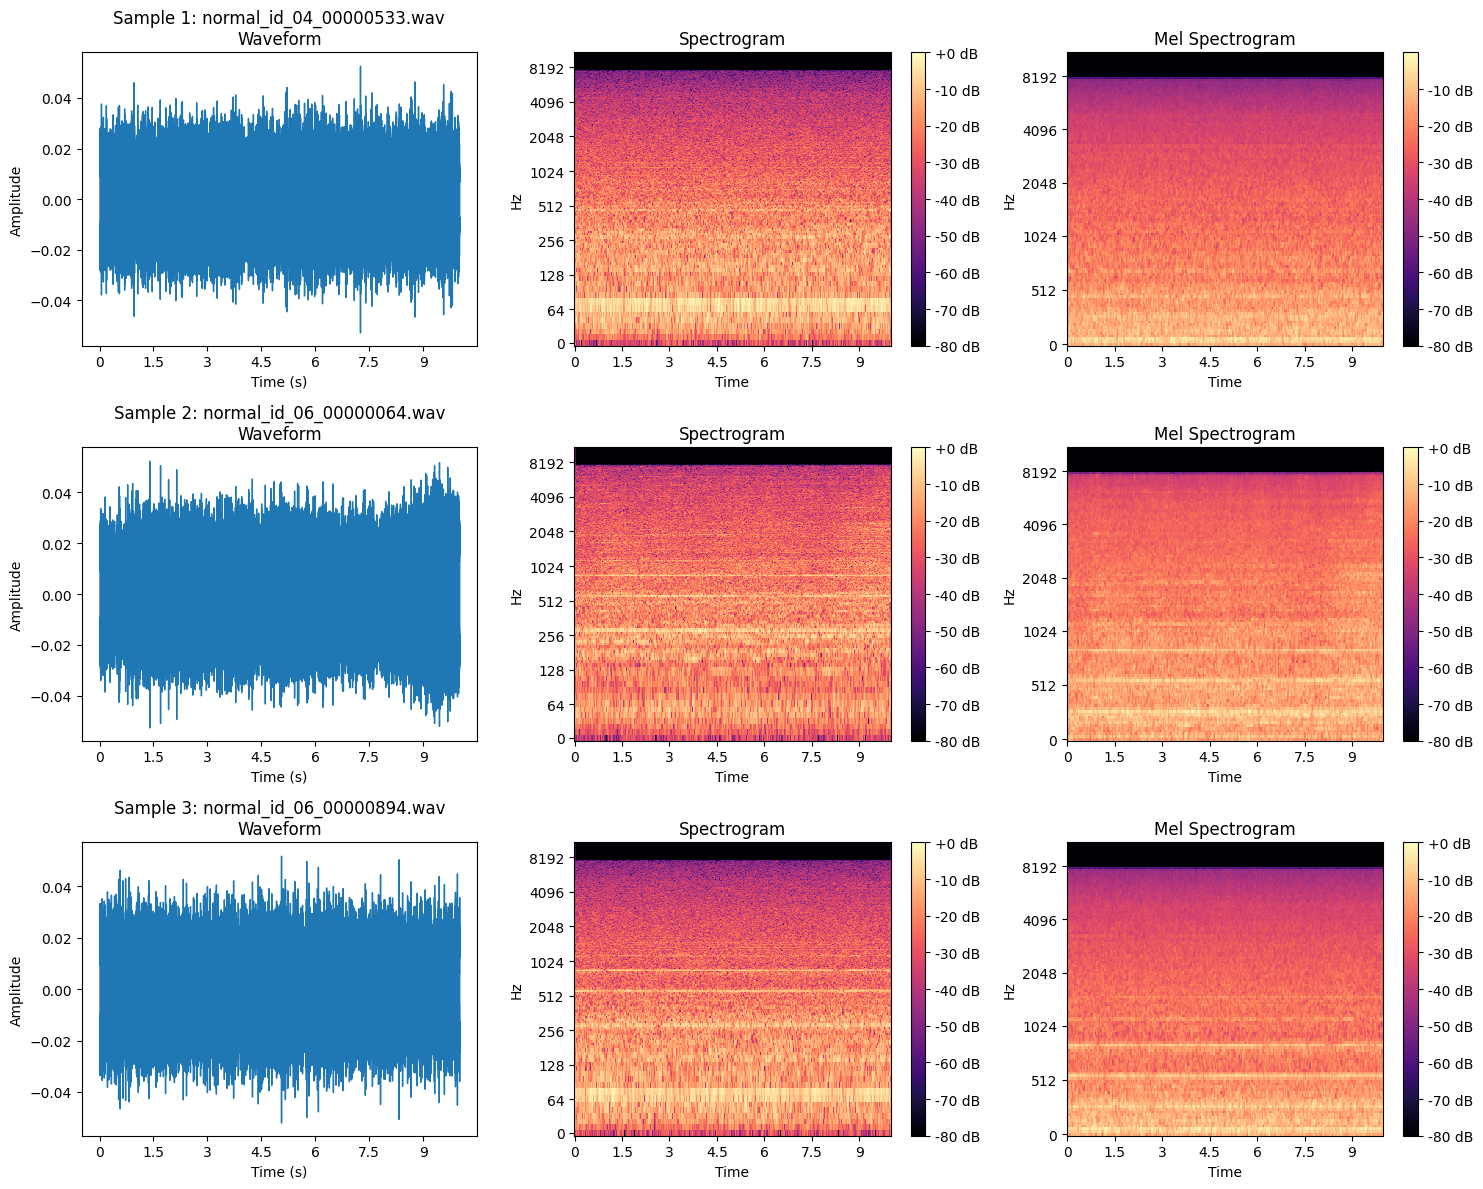

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
# Cell 4: Visualize audio samples
def plot_audio_comparison(audio_list, titles=None):
    """Plot multiple audio samples for comparison"""
    n_samples = len(audio_list)
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 4*n_samples))
    
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i, audio_data in enumerate(audio_list):
        audio = audio_data['audio']
        sr = audio_data['sr']
        
        # Waveform
        librosa.display.waveshow(audio, sr=sr, ax=axes[i, 0])
        title = titles[i] if titles else f"Sample {i+1}: {audio_data['file_name']}"
        axes[i, 0].set_title(f'{title}\nWaveform')
        axes[i, 0].set_xlabel('Time (s)')
        axes[i, 0].set_ylabel('Amplitude')
        
        # Spectrogram
        D = librosa.amplitude_to_db(np.abs(librosa.stft(audio)), ref=np.max)
        img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', 
                                       ax=axes[i, 1])
        axes[i, 1].set_title('Spectrogram')
        fig.colorbar(img, ax=axes[i, 1], format='%+2.0f dB')
        
        # Mel spectrogram
        mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        img2 = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', 
                                        y_axis='mel', ax=axes[i, 2])
        axes[i, 2].set_title('Mel Spectrogram')
        fig.colorbar(img2, ax=axes[i, 2], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()

# Visualize first few samples
if sample_audio_data:
    plot_audio_comparison(sample_audio_data[:3])

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
# Cell 5: Feature extraction pipeline
class AudioFeatureExtractor:
    """Extract features from audio files for anomaly detection"""
    
    def __init__(self, sr=22050, n_mels=128, n_mfcc=20, segment_duration=2.0, overlap=0.5):
        self.sr = sr
        self.n_mels = n_mels
        self.n_mfcc = n_mfcc
        self.segment_duration = segment_duration
        self.overlap = overlap
        self.segment_length = int(segment_duration * sr)
        self.hop_length = int(self.segment_length * (1 - overlap))
        
    def create_segments(self, audio):
        """Split audio into overlapping segments"""
        segments = []
        for start in range(0, len(audio) - self.segment_length + 1, self.hop_length):
            segment = audio[start:start + self.segment_length]
            segments.append(segment)
        return segments
    
    def extract_log_mel_spectrogram(self, segment):
        """Extract log-mel spectrogram from audio segment"""
        # Ensure segment has correct length
        if len(segment) < self.segment_length:
            segment = np.pad(segment, (0, self.segment_length - len(segment)))
        
        # Extract mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=segment, 
            sr=self.sr, 
            n_mels=self.n_mels,
            n_fft=2048,
            hop_length=512
        )
        
        # Convert to log scale
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        
        return log_mel_spec
    
    def extract_mfcc_features(self, segment):
        """Extract MFCC features"""
        mfccs = librosa.feature.mfcc(
            y=segment, 
            sr=self.sr, 
            n_mfcc=self.n_mfcc,
            n_fft=2048,
            hop_length=512
        )
        return mfccs
    
    def extract_spectral_features(self, segment):
        """Extract spectral features"""
        spectral_centroid = librosa.feature.spectral_centroid(
            y=segment, sr=self.sr, n_fft=2048, hop_length=512
        )
        spectral_bandwidth = librosa.feature.spectral_bandwidth(
            y=segment, sr=self.sr, n_fft=2048, hop_length=512
        )
        spectral_rolloff = librosa.feature.spectral_rolloff(
            y=segment, sr=self.sr, n_fft=2048, hop_length=512
        )
        zero_crossing = librosa.feature.zero_crossing_rate(segment)
        rms = librosa.feature.rms(y=segment)
        
        return {
            'spectral_centroid': spectral_centroid,
            'spectral_bandwidth': spectral_bandwidth,
            'spectral_rolloff': spectral_rolloff,
            'zero_crossing': zero_crossing,
            'rms': rms
        }
    
    def process_audio_file(self, file_path, max_duration=None):
        """Process complete audio file and extract features"""
        # Load audio
        audio_data = load_audio_with_info(file_path, self.sr, max_duration)
        if audio_data is None:
            return None
        
        audio = audio_data['audio']
        
        # Create segments
        segments = self.create_segments(audio)
        
        # Extract features for each segment
        log_mel_specs = []
        mfcc_features = []
        spectral_features = []
        
        for segment in segments:
            # Log-mel spectrogram
            log_mel = self.extract_log_mel_spectrogram(segment)
            log_mel_specs.append(log_mel)
            
            # MFCC features
            mfcc = self.extract_mfcc_features(segment)
            mfcc_features.append(mfcc)
            
            # Spectral features
            spectral = self.extract_spectral_features(segment)
            spectral_features.append(spectral)
        
        return {
            'file_path': file_path,
            'audio': audio,
            'segments': segments,
            'log_mel_specs': log_mel_specs,
            'mfcc_features': mfcc_features,
            'spectral_features': spectral_features,
            'num_segments': len(segments)
        }

# Test the feature extractor
print("Testing feature extractor...")
extractor = AudioFeatureExtractor(sr=22050, segment_duration=2.0, overlap=0.5)

if sample_audio_data:
    test_file = sample_audio_data[0]['file_path']
    features = extractor.process_audio_file(test_file, max_duration=5)
    
    if features:
        print(f"\nExtracted features from: {os.path.basename(test_file)}")
        print(f"Number of segments: {features['num_segments']}")
        print(f"Log-mel spectrogram shape: {features['log_mel_specs'][0].shape}")
        print(f"MFCC features shape: {features['mfcc_features'][0].shape}")

Testing feature extractor...

Extracted features from: normal_id_04_00000533.wav
Number of segments: 4
Log-mel spectrogram shape: (128, 87)
MFCC features shape: (20, 87)


In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
# Cell 6: Build dataset from audio files
def build_dataset_from_files(audio_files, extractor, max_files=None, max_duration=None):
    """Build complete dataset from audio files"""
    all_log_mel = []
    all_mfcc = []
    file_indices = []
    segment_indices = []
    
    print("Building dataset from audio files...")
    
    files_to_process = audio_files[:max_files] if max_files else audio_files
    
    for file_idx, file_path in enumerate(tqdm(files_to_process, desc="Processing files")):
        # Process audio file
        features = extractor.process_audio_file(file_path, max_duration)
        
        if features is None:
            continue
        
        # Process each segment
        for seg_idx, log_mel in enumerate(features['log_mel_specs']):
            # Standardize spectrogram dimensions
            target_height = extractor.n_mels
            target_width = 87  # Standard width for 2-second segments at 22050 Hz
            
            # Resize if necessary
            if log_mel.shape[0] != target_height:
                # Resize height (mel bands)
                log_mel = log_mel[:target_height, :] if log_mel.shape[0] > target_height else np.vstack([log_mel, np.zeros((target_height - log_mel.shape[0], log_mel.shape[1]))])
            
            if log_mel.shape[1] > target_width:
                # Trim width
                log_mel = log_mel[:, :target_width]
            elif log_mel.shape[1] < target_width:
                # Pad width
                pad_width = target_width - log_mel.shape[1]
                log_mel = np.pad(log_mel, ((0, 0), (0, pad_width)), mode='constant')
            
            # Normalize
            log_mel_normalized = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
            
            # Store
            all_log_mel.append(log_mel_normalized)
            file_indices.append(file_idx)
            segment_indices.append(seg_idx)
    
    # Convert to numpy arrays
    X_log_mel = np.array(all_log_mel)
    
    print(f"\nDataset built successfully!")
    print(f"Total segments: {len(all_log_mel)}")
    print(f"Log-mel spectrogram shape: {X_log_mel.shape}")
    
    return {
        'X_log_mel': X_log_mel,
        'file_indices': np.array(file_indices),
        'segment_indices': np.array(segment_indices)
    }

# Build initial dataset
print("\nBuilding initial dataset...")
extractor = AudioFeatureExtractor(sr=22050, segment_duration=2.0, overlap=0.5)

# Use first 10 files as training (normal operation)
train_files = audio_files[:-1] if len(audio_files) >= 10 else audio_files
train_dataset = build_dataset_from_files(train_files, extractor, max_duration=30)

X_train = train_dataset['X_log_mel']

# Add channel dimension for CNN
X_train_cnn = X_train[..., np.newaxis]
print(f"Training data shape for CNN: {X_train_cnn.shape}")


Building initial dataset...
Building dataset from audio files...


Processing files: 100%|██████████| 29/29 [00:05<00:00,  5.14it/s]


Dataset built successfully!
Total segments: 261
Log-mel spectrogram shape: (261, 128, 87)
Training data shape for CNN: (261, 128, 87, 1)


In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# Cell 7: Build Convolutional Autoencoder with proper dimensions
def build_convolutional_autoencoder(input_shape):
    """
    Build a convolutional autoencoder for anomaly detection.
    Handles dimension matching properly.
    """
    print(f"Building autoencoder for input shape: {input_shape}")
    
    # Input layer
    inputs = layers.Input(shape=input_shape)
    
    # ---------- ENCODER ----------
    # Block 1
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 64 x 44
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)  # 32 x 22
    
    # Block 3
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)  # 16 x 11
    
    # ---------- BOTTLENECK ----------
    bottleneck = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    bottleneck = layers.BatchNormalization()(bottleneck)
    
    # ---------- DECODER ----------
    # Block 1
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(bottleneck)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)  # 32 x 22
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)  # 64 x 44
    
    # Block 3
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.UpSampling2D((2, 2))(x)  # 128 x 88
    
    # Adjust dimensions if needed
    if x.shape[2] > input_shape[1]:
        # Crop if too wide
        crop_amount = x.shape[2] - input_shape[1]
        x = layers.Cropping2D(((0, 0), (0, crop_amount)))(x)
    elif x.shape[2] < input_shape[1]:
        # Pad if too narrow
        pad_amount = input_shape[1] - x.shape[2]
        x = layers.ZeroPadding2D(((0, 0), (0, pad_amount)))(x)
    
    # Output layer
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    # Create models
    autoencoder = Model(inputs, decoded, name='autoencoder')
    encoder_model = Model(inputs, encoded, name='encoder')
    
    # Compile autoencoder
    autoencoder.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    print("\nAutoencoder Summary:")
    autoencoder.summary()
    
    return autoencoder, encoder_model

# Build the autoencoder
input_shape = X_train_cnn.shape[1:]  # (128, 87, 1)
autoencoder, encoder = build_convolutional_autoencoder(input_shape)

Building autoencoder for input shape: (128, 87, 1)

Autoencoder Summary:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 128, 87, 1)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 87, 32)         │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 87, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 44, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 44, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 44, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 22, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 22, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 11, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 11, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 16, 11, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 16, 11, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 32, 22, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 22, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32, 22, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 64, 44, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 334,913 (1.28 MB)

 Trainable params: 333,889 (1.27 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
# Cell 8: Train the autoencoder
def train_autoencoder_model(autoencoder, X_train, X_val=None, epochs=50, batch_size=32, validation_split=0.2):
    """Train the autoencoder model"""
    
    # Prepare callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss' if X_val is not None else 'loss',
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss' if X_val is not None else 'loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=1
        )
    ]
    
    print(f"Training autoencoder...")
    print(f"Training samples: {len(X_train)}")
    print(f"Batch size: {batch_size}")
    print(f"Epochs: {epochs}")
    
    # Train the model
    if X_val is not None:
        history = autoencoder.fit(
            X_train, X_train,
            validation_data=(X_val, X_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1,
            shuffle=True
        )
    else:
        history = autoencoder.fit(
            X_train, X_train,
            validation_split=validation_split,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1,
            shuffle=True
        )
    
    return history

# Split data for training
np.random.seed(42)
indices = np.random.permutation(len(X_train_cnn))
train_size = int(0.8 * len(X_train_cnn))

train_indices = indices[:train_size]
val_indices = indices[train_size:]

X_train_split = X_train_cnn[train_indices]
X_val_split = X_train_cnn[val_indices]

print(f"Training set size: {len(X_train_split)}")
print(f"Validation set size: {len(X_val_split)}")

# Train the model
history = train_autoencoder_model(
    autoencoder, 
    X_train_split, 
    X_val_split,
    epochs=2, # 30, # ---------change for reproducing purposes----------
    batch_size=16
)

Training set size: 208
Validation set size: 53
Training autoencoder...
Training samples: 208
Batch size: 16
Epochs: 2
Epoch 1/2
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 317ms/step - loss: 0.0489 - mae: 0.1522 - val_loss: 0.0501 - val_mae: 0.1661 - learning_rate: 0.0010
Epoch 2/2
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - loss: 0.0032 - mae: 0.0417 - val_loss: 0.0481 - val_mae: 0.1519 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 2.


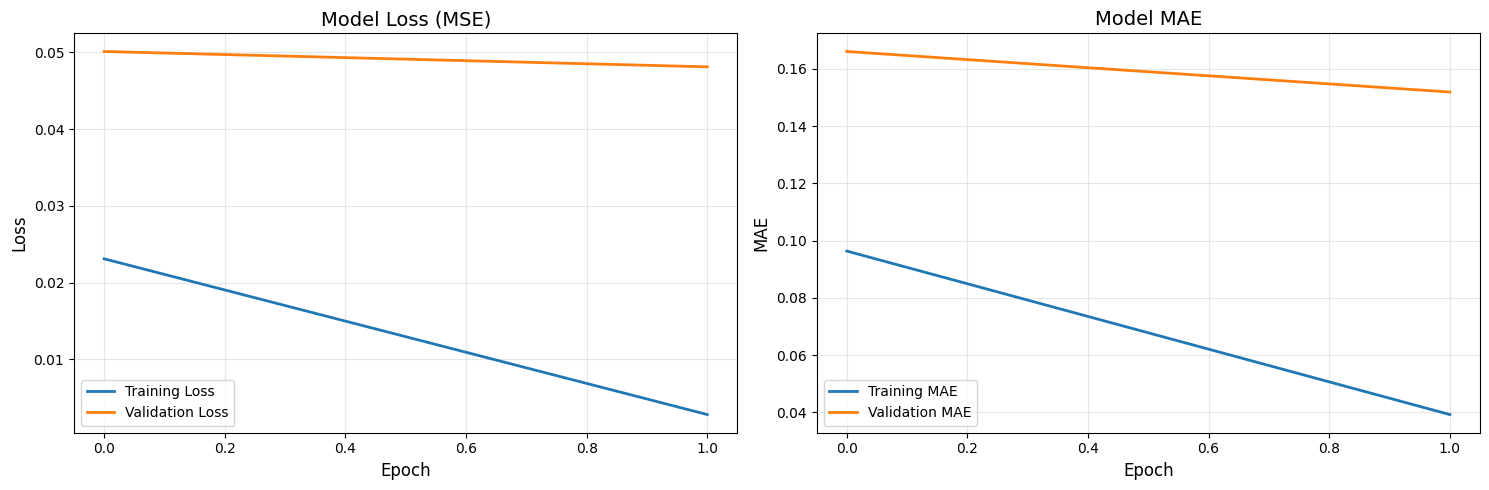


Training Results:
Final Training Loss: 0.002815
Final Validation Loss: 0.048105
Final Training MAE: 0.039230
Final Validation MAE: 0.151948


In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
# Cell 9: Visualize training progress
def plot_training_progress(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot loss
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[0].set_title('Model Loss (MSE)', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot MAE
    if 'mae' in history.history:
        axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
        axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
        axes[1].set_title('Model MAE', fontsize=14)
        axes[1].set_xlabel('Epoch', fontsize=12)
        axes[1].set_ylabel('MAE', fontsize=12)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print("\nTraining Results:")
    print(f"Final Training Loss: {history.history['loss'][-1]:.6f}")
    print(f"Final Validation Loss: {history.history['val_loss'][-1]:.6f}")
    if 'mae' in history.history:
        print(f"Final Training MAE: {history.history['mae'][-1]:.6f}")
        print(f"Final Validation MAE: {history.history['val_mae'][-1]:.6f}")

plot_training_progress(history)

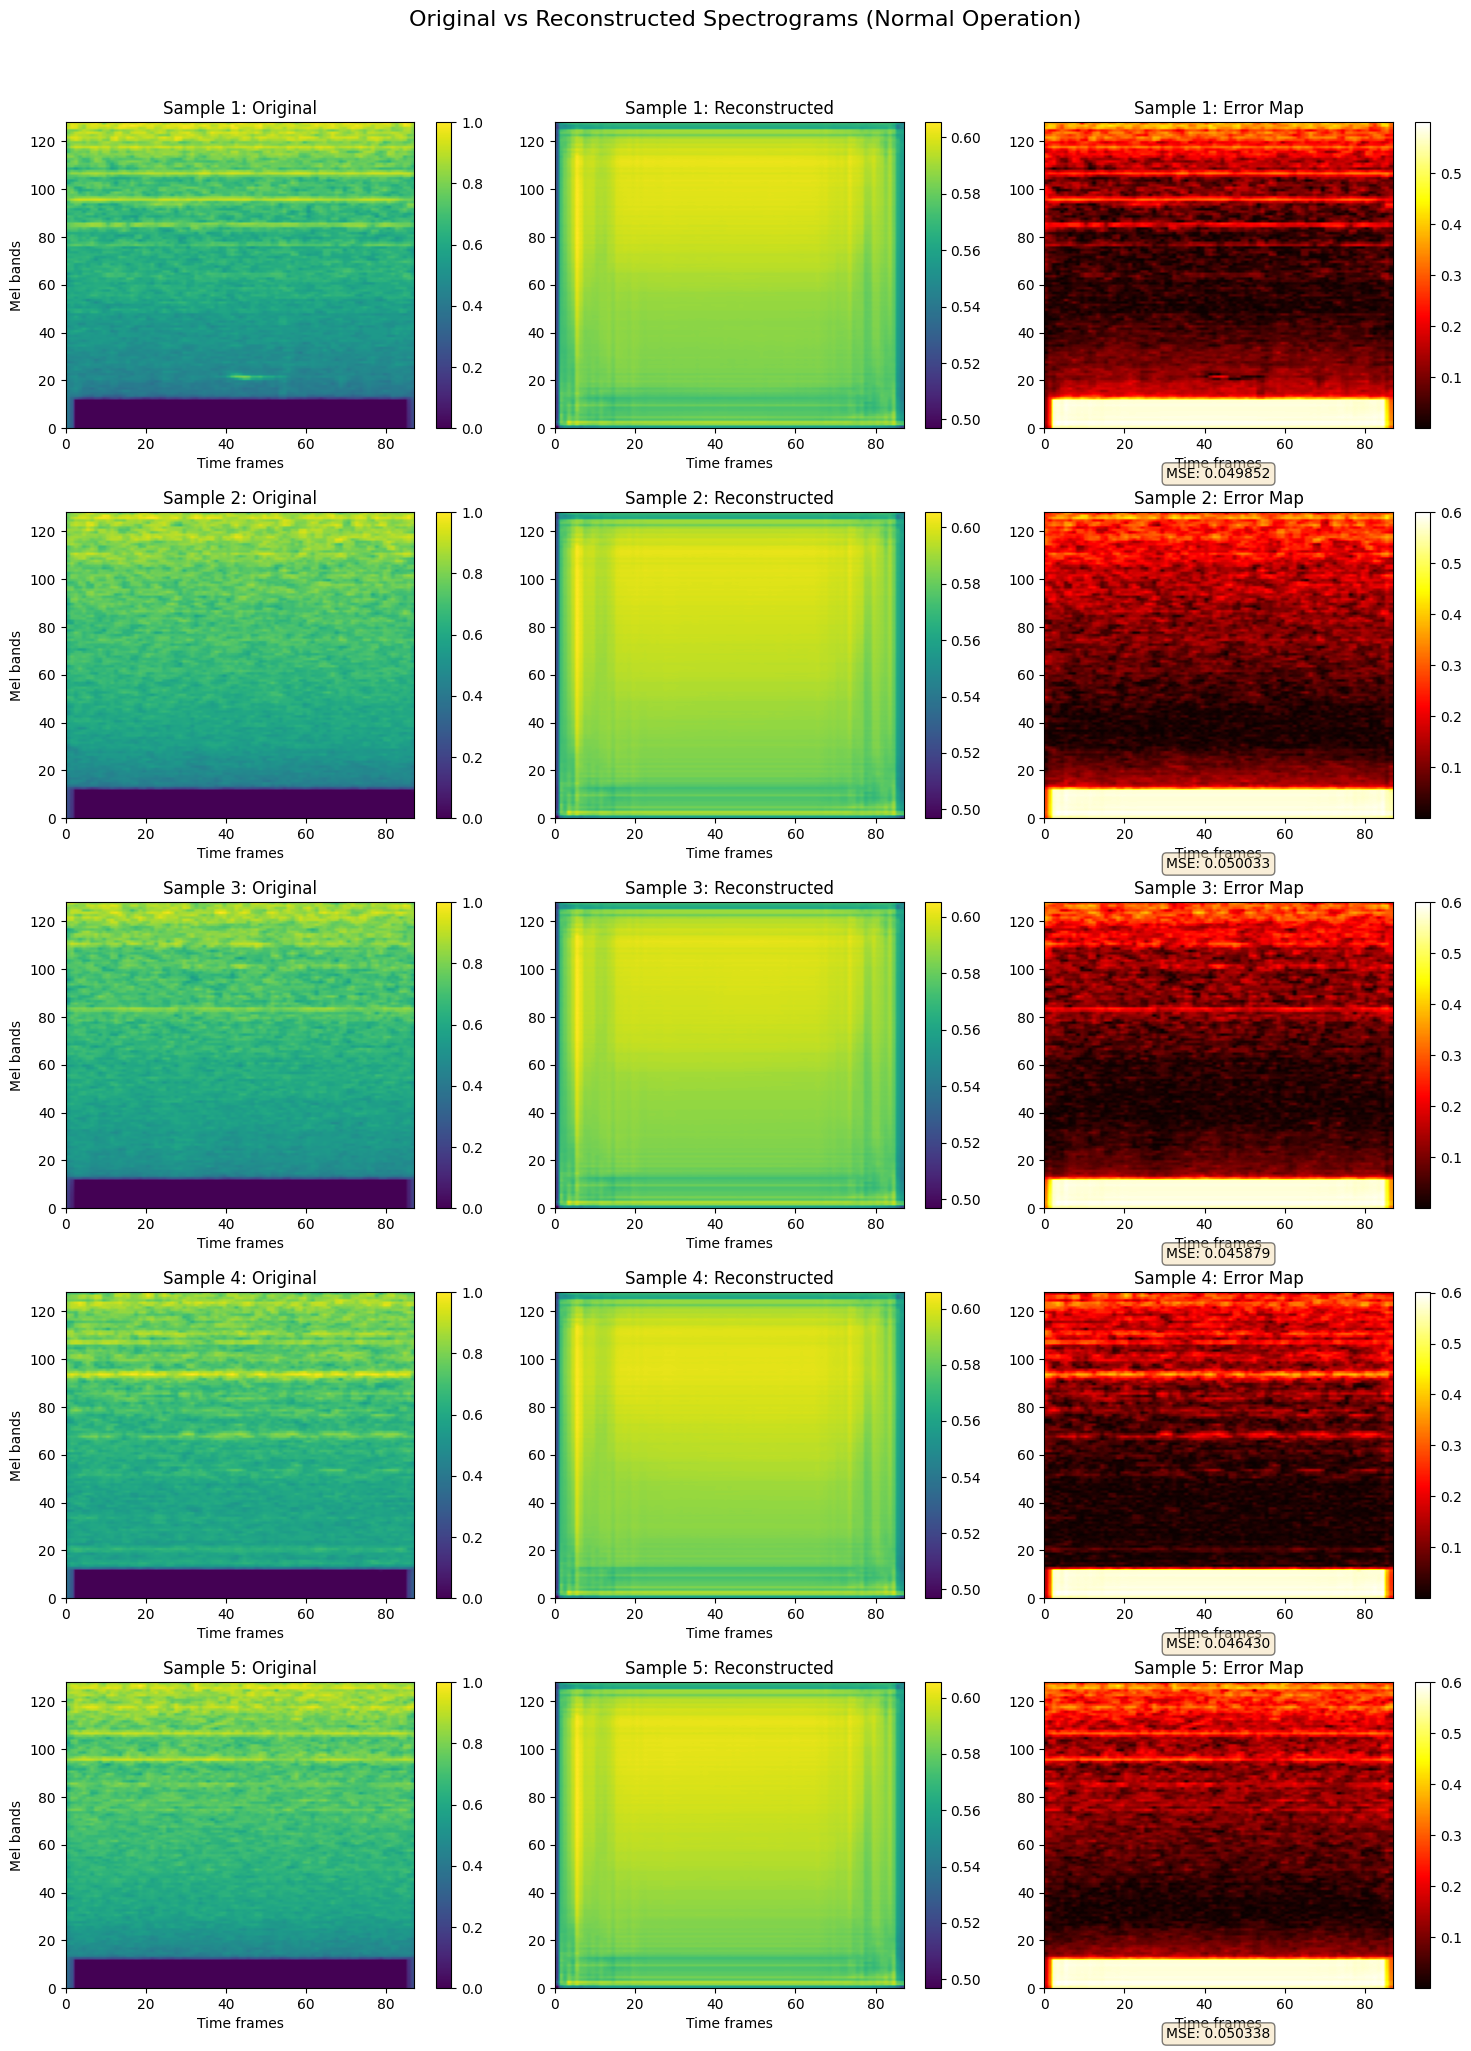

In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
# Cell 10: Visualize reconstructions on normal data
def visualize_reconstructions(autoencoder, X_samples, n_samples=5):
    """Visualize original vs reconstructed spectrograms"""
    
    # Get reconstructions
    reconstructions = autoencoder.predict(X_samples[:n_samples], verbose=0)
    
    fig, axes = plt.subplots(n_samples, 3, figsize=(15, 4*n_samples))
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Original vs Reconstructed Spectrograms (Normal Operation)', fontsize=16, y=1.02)
    
    for i in range(n_samples):
        # Original
        im1 = axes[i, 0].imshow(X_samples[i, :, :, 0], aspect='auto', cmap='viridis', 
                               extent=[0, X_samples[i].shape[1], 0, X_samples[i].shape[0]])
        axes[i, 0].set_title(f'Sample {i+1}: Original', fontsize=12)
        axes[i, 0].set_xlabel('Time frames', fontsize=10)
        axes[i, 0].set_ylabel('Mel bands', fontsize=10)
        plt.colorbar(im1, ax=axes[i, 0])
        
        # Reconstructed
        im2 = axes[i, 1].imshow(reconstructions[i, :, :, 0], aspect='auto', cmap='viridis',
                               extent=[0, reconstructions[i].shape[1], 0, reconstructions[i].shape[0]])
        axes[i, 1].set_title(f'Sample {i+1}: Reconstructed', fontsize=12)
        axes[i, 1].set_xlabel('Time frames', fontsize=10)
        plt.colorbar(im2, ax=axes[i, 1])
        
        # Error map
        error = np.abs(X_samples[i] - reconstructions[i])
        im3 = axes[i, 2].imshow(error[:, :, 0], aspect='auto', cmap='hot',
                               extent=[0, error.shape[1], 0, error.shape[0]])
        axes[i, 2].set_title(f'Sample {i+1}: Error Map', fontsize=12)
        axes[i, 2].set_xlabel('Time frames', fontsize=10)
        plt.colorbar(im3, ax=axes[i, 2])
        
        # Calculate and display MSE
        mse = np.mean(error**2)
        axes[i, 2].text(0.5, -0.15, f'MSE: {mse:.6f}', 
                       transform=axes[i, 2].transAxes, 
                       ha='center', va='center', fontsize=10, 
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

# Select random normal samples
np.random.seed(42)
sample_indices = np.random.choice(len(X_train_split), 5, replace=False)
X_samples = X_train_split[sample_indices]

visualize_reconstructions(autoencoder, X_samples)

Calculating reconstruction errors for 208 samples...


Processing: 100%|██████████| 208/208 [00:00<00:00, 47354.68it/s]



Reconstruction Error Statistics:
  Min: 0.039548
  Max: 0.068744
  Mean: 0.049558
  Std: 0.005669
  95th percentile: 0.063343
  99th percentile: 0.067476

Anomaly Threshold (based on 99th percentile): 0.067476


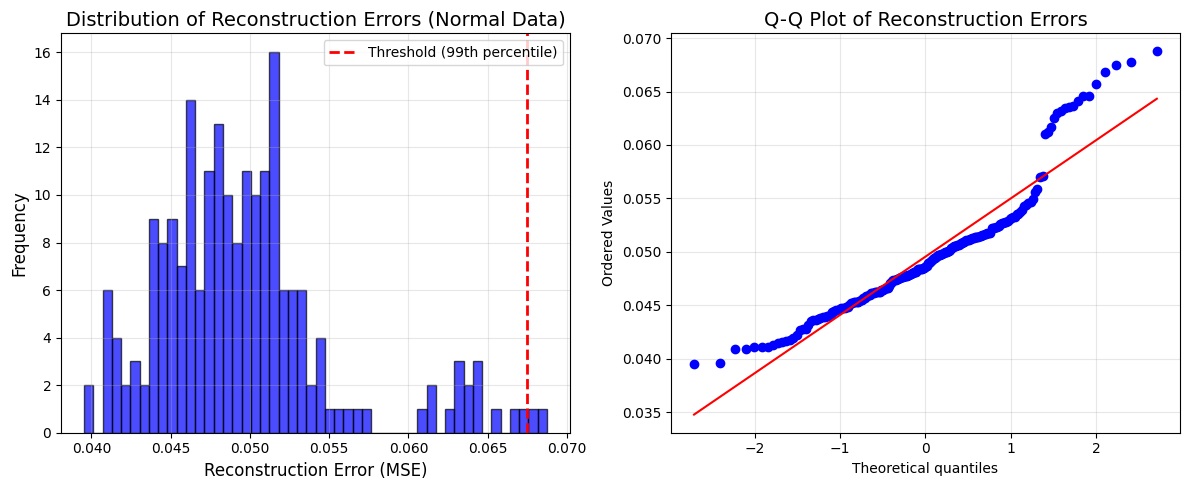

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
# Cell 11: Calculate reconstruction errors and set threshold
def calculate_reconstruction_errors(autoencoder, X_data):
    """Calculate reconstruction errors for data"""
    print(f"Calculating reconstruction errors for {len(X_data)} samples...")
    
    # Get reconstructions
    reconstructions = autoencoder.predict(X_data, verbose=0)
    
    # Calculate MSE for each sample
    reconstruction_errors = []
    for i in tqdm(range(len(X_data)), desc="Processing"):
        mse = np.mean((X_data[i] - reconstructions[i]) ** 2)
        reconstruction_errors.append(mse)
    
    reconstruction_errors = np.array(reconstruction_errors)
    
    print(f"\nReconstruction Error Statistics:")
    print(f"  Min: {reconstruction_errors.min():.6f}")
    print(f"  Max: {reconstruction_errors.max():.6f}")
    print(f"  Mean: {reconstruction_errors.mean():.6f}")
    print(f"  Std: {reconstruction_errors.std():.6f}")
    print(f"  95th percentile: {np.percentile(reconstruction_errors, 95):.6f}")
    print(f"  99th percentile: {np.percentile(reconstruction_errors, 99):.6f}")
    
    return reconstruction_errors, reconstructions

# Calculate errors on normal (training) data
train_errors, train_reconstructions = calculate_reconstruction_errors(autoencoder, X_train_split)

# Set anomaly threshold (based on normal data)
threshold_percentile = 99  # Conservative threshold
anomaly_threshold = np.percentile(train_errors, threshold_percentile)

print(f"\nAnomaly Threshold (based on {threshold_percentile}th percentile): {anomaly_threshold:.6f}")

# Plot distribution of reconstruction errors
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train_errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(x=anomaly_threshold, color='red', linestyle='--', linewidth=2, 
           label=f'Threshold ({threshold_percentile}th percentile)')
plt.title('Distribution of Reconstruction Errors (Normal Data)', fontsize=14)
plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
stats.probplot(train_errors, dist="norm", plot=plt)
plt.title('Q-Q Plot of Reconstruction Errors', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
import os

path = "data/get-well-soon-fadfouda-istamta3"

num_files = sum(
    len(files) for _, _, files in os.walk(path)
)

print(f"Total files in dataset: {num_files}")

Total files in dataset: 30


Building test dataset from 30 files...
Building dataset from audio files...


Processing files: 100%|██████████| 30/30 [00:05<00:00,  5.18it/s]



Dataset built successfully!
Total segments: 270
Log-mel spectrogram shape: (270, 128, 87)
Test data shape: (270, 128, 87, 1)
Calculating reconstruction errors for 270 samples...


Processing: 100%|██████████| 270/270 [00:00<00:00, 49446.01it/s]



Reconstruction Error Statistics:
  Min: 0.038484
  Max: 0.067021
  Mean: 0.047892
  Std: 0.004977
  95th percentile: 0.055799
  99th percentile: 0.062554

Anomaly Detection Results:
Total test samples: 270
Anomalies detected: 0
Anomaly rate: 0.00%


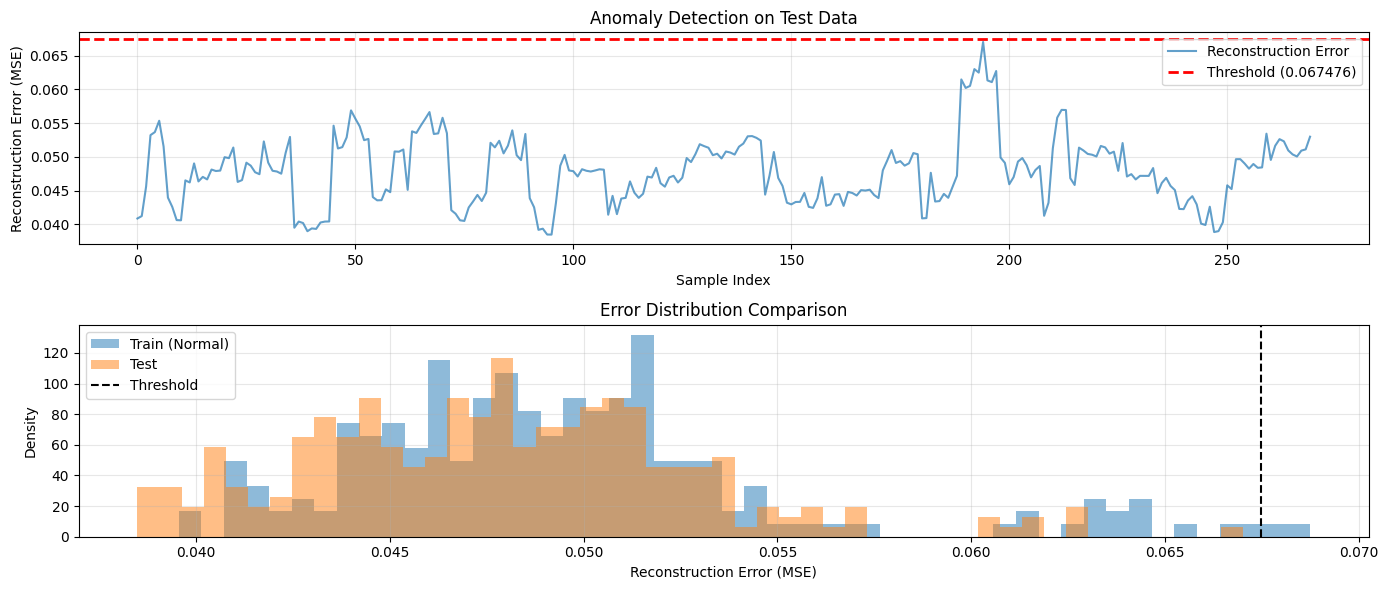

In [13]:
# --- [CELL 12]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 13}
# cell_12

import os
import numpy as np
import matplotlib.pyplot as plt

# Path to test dataset
path = "data/get-well-soon-fadfouda-istamta3"

# Collect ALL audio files from the path
audio_extensions = (".wav", ".mp3", ".flac", ".ogg", ".m4a")

test_files = [
    os.path.join(root, file)
    for root, _, files in os.walk(path)
    for file in files
    if file.lower().endswith(audio_extensions)
]

print(f"Building test dataset from {len(test_files)} files...")

# Stop safely if no files found
if len(test_files) == 0:
    raise RuntimeError("❌ No audio files found in the test dataset path.")

# Build test dataset
test_dataset = build_dataset_from_files(
    test_files,
    extractor,
    max_duration=30
)

X_test = test_dataset["X_log_mel"][..., np.newaxis]

print(f"Test data shape: {X_test.shape}")

# Stop if no segments were produced
if X_test.shape[0] == 0:
    raise RuntimeError("❌ Audio files found, but no valid segments were extracted.")

# Calculate reconstruction errors
test_errors, test_reconstructions = calculate_reconstruction_errors(
    autoencoder,
    X_test
)

# Detect anomalies
test_anomalies = test_errors > anomaly_threshold
num_anomalies = np.sum(test_anomalies)

print("\nAnomaly Detection Results:")
print(f"Total test samples: {len(test_errors)}")
print(f"Anomalies detected: {num_anomalies}")
print(f"Anomaly rate: {num_anomalies / len(test_errors) * 100:.2f}%")

# =========================
# Visualization
# =========================

plt.figure(figsize=(14, 6))

# Time series of reconstruction errors
plt.subplot(2, 1, 1)
plt.plot(test_errors, alpha=0.7, label="Reconstruction Error")
plt.axhline(
    y=anomaly_threshold,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Threshold ({anomaly_threshold:.6f})"
)

anomaly_indices = np.where(test_anomalies)[0]
if len(anomaly_indices) > 0:
    plt.scatter(
        anomaly_indices,
        test_errors[anomaly_indices],
        color="red",
        s=40,
        label="Anomalies"
    )

plt.title("Anomaly Detection on Test Data")
plt.xlabel("Sample Index")
plt.ylabel("Reconstruction Error (MSE)")
plt.legend()
plt.grid(alpha=0.3)

# Distribution comparison
plt.subplot(2, 1, 2)
plt.hist(train_errors, bins=50, density=True, alpha=0.5, label="Train (Normal)")
plt.hist(test_errors, bins=50, density=True, alpha=0.5, label="Test")
plt.axvline(anomaly_threshold, color="black", linestyle="--", label="Threshold")

plt.title("Error Distribution Comparison")
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# --- [CELL 13]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 14}
# Cell 13: Visualize anomalous samples
def visualize_anomalous_samples(X_data, errors, reconstructions, threshold, max_samples=5):
    """Visualize samples with highest reconstruction errors"""
    
    # Find anomalous samples
    anomaly_indices = np.where(errors > threshold)[0]
    
    if len(anomaly_indices) == 0:
        print("No anomalies detected!")
        return
    
    # Sort by error (highest first)
    sorted_indices = anomaly_indices[np.argsort(errors[anomaly_indices])[::-1]]
    display_indices = sorted_indices[:min(max_samples, len(sorted_indices))]
    
    print(f"Visualizing top {len(display_indices)} anomalous samples...")
    
    fig, axes = plt.subplots(len(display_indices), 3, figsize=(15, 4*len(display_indices)))
    if len(display_indices) == 1:
        axes = axes.reshape(1, -1)
    
    fig.suptitle('Anomalous Samples Analysis', fontsize=16, y=1.02)
    
    for idx, sample_idx in enumerate(display_indices):
        # Original
        im1 = axes[idx, 0].imshow(X_data[sample_idx, :, :, 0], aspect='auto', cmap='viridis')
        axes[idx, 0].set_title(f'Anomaly {idx+1}: Original\nError: {errors[sample_idx]:.6f}', fontsize=12)
        axes[idx, 0].set_xlabel('Time frames', fontsize=10)
        axes[idx, 0].set_ylabel('Mel bands', fontsize=10)
        plt.colorbar(im1, ax=axes[idx, 0])
        
        # Reconstructed
        im2 = axes[idx, 1].imshow(reconstructions[sample_idx, :, :, 0], aspect='auto', cmap='viridis')
        axes[idx, 1].set_title(f'Anomaly {idx+1}: Reconstructed', fontsize=12)
        axes[idx, 1].set_xlabel('Time frames', fontsize=10)
        plt.colorbar(im2, ax=axes[idx, 1])
        
        # Error heatmap
        error_map = np.abs(X_data[sample_idx] - reconstructions[sample_idx])
        im3 = axes[idx, 2].imshow(error_map[:, :, 0], aspect='auto', cmap='hot')
        axes[idx, 2].set_title(f'Anomaly {idx+1}: Error Heatmap', fontsize=12)
        axes[idx, 2].set_xlabel('Time frames', fontsize=10)
        plt.colorbar(im3, ax=axes[idx, 2])
        
        # Mark where error exceeds threshold
        threshold_error = np.percentile(error_map, 95)
        high_error_points = error_map > threshold_error
        
        # Overlay high error points
        y_coords, x_coords = np.where(high_error_points[:, :, 0])
        axes[idx, 2].scatter(x_coords, y_coords, color='cyan', s=10, alpha=0.6, 
                           label='High Error Regions')
        
        if idx == 0:
            axes[idx, 2].legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Visualize anomalous samples from test data
visualize_anomalous_samples(X_test, test_errors, test_reconstructions, anomaly_threshold)

No anomalies detected!


Running early warning analysis...


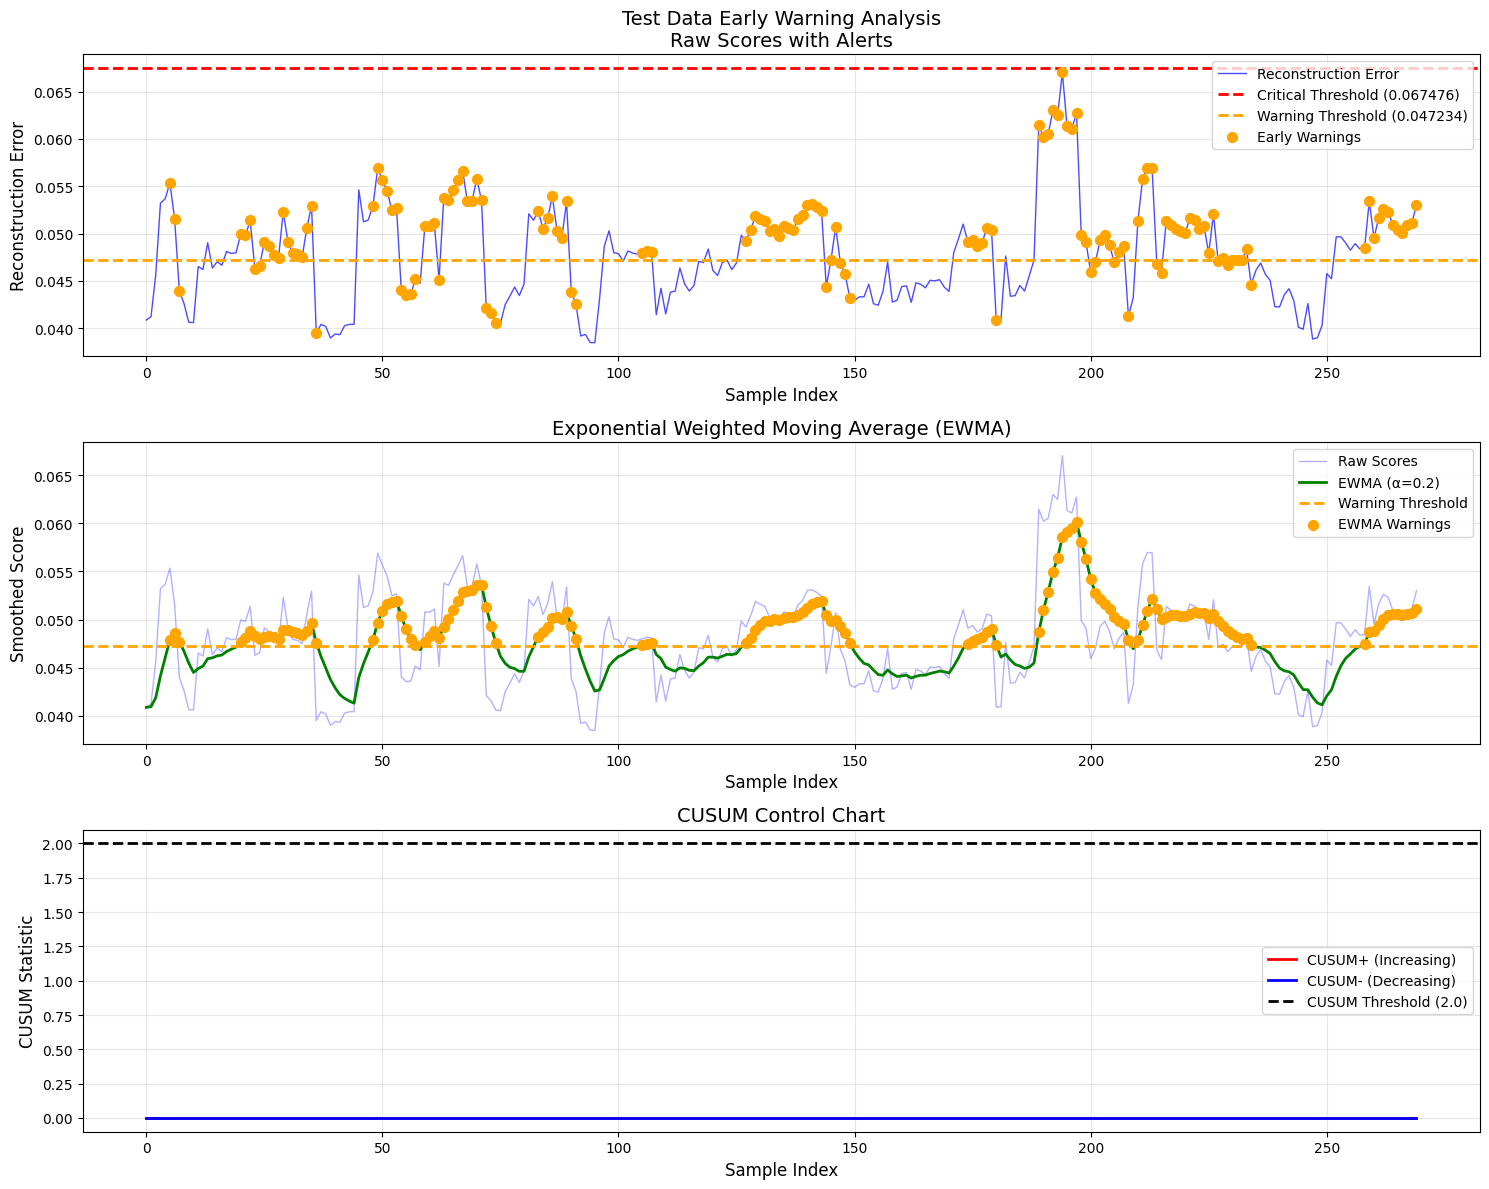

In [15]:
# --- [CELL 14]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 15}
# Cell 14: Temporal analysis for early warning (EWMA and CUSUM)
class EarlyWarningSystem:
    """Implement early warning system using EWMA and CUSUM"""
    
    def __init__(self, threshold, ewma_alpha=0.3, cusum_threshold=3, drift=0.5):
        self.threshold = threshold
        self.ewma_alpha = ewma_alpha
        self.cusum_threshold = cusum_threshold
        self.drift = drift
        
    def calculate_ewma(self, scores):
        """Calculate Exponential Weighted Moving Average"""
        ewma = np.zeros_like(scores)
        ewma[0] = scores[0]
        
        for i in range(1, len(scores)):
            ewma[i] = self.ewma_alpha * scores[i] + (1 - self.ewma_alpha) * ewma[i-1]
        
        return ewma
    
    def calculate_cusum(self, scores):
        """Calculate CUSUM statistics"""
        n = len(scores)
        cusum_pos = np.zeros(n)  # For positive shifts (increasing errors)
        cusum_neg = np.zeros(n)  # For negative shifts (decreasing errors)
        
        for i in range(1, n):
            cusum_pos[i] = max(0, cusum_pos[i-1] + scores[i] - self.drift)
            cusum_neg[i] = max(0, cusum_neg[i-1] - scores[i] - self.drift)
        
        return cusum_pos, cusum_neg
    
    def detect_early_warnings(self, scores):
        """Detect early warnings using multiple methods"""
        # Calculate statistics
        ewma = self.calculate_ewma(scores)
        cusum_pos, cusum_neg = self.calculate_cusum(scores)
        
        # Detect warnings
        ewma_warnings = ewma > (self.threshold * 0.7)  # Warning at 70% of threshold
        cusum_warnings = cusum_pos > self.cusum_threshold
        
        # Combine warnings
        early_warnings = ewma_warnings | cusum_warnings
        
        # Find critical anomalies
        critical_anomalies = scores > self.threshold
        
        return {
            'scores': scores,
            'ewma': ewma,
            'cusum_pos': cusum_pos,
            'cusum_neg': cusum_neg,
            'ewma_warnings': ewma_warnings,
            'cusum_warnings': cusum_warnings,
            'early_warnings': early_warnings,
            'critical_anomalies': critical_anomalies,
            'warning_threshold': self.threshold * 0.7,
            'critical_threshold': self.threshold
        }
    
    def plot_early_warnings(self, results, title="Early Warning Analysis"):
        """Plot early warning analysis"""
        fig, axes = plt.subplots(3, 1, figsize=(15, 12))
        
        # Plot 1: Raw scores with thresholds
        axes[0].plot(results['scores'], 'b-', alpha=0.7, linewidth=1, label='Reconstruction Error')
        axes[0].axhline(y=results['critical_threshold'], color='r', linestyle='--', 
                       linewidth=2, label=f'Critical Threshold ({results["critical_threshold"]:.6f})')
        axes[0].axhline(y=results['warning_threshold'], color='orange', linestyle='--',
                       linewidth=2, label=f'Warning Threshold ({results["warning_threshold"]:.6f})')
        
        # Mark warnings and critical points
        warning_indices = np.where(results['early_warnings'])[0]
        critical_indices = np.where(results['critical_anomalies'])[0]
        
        if len(warning_indices) > 0:
            axes[0].scatter(warning_indices, results['scores'][warning_indices],
                          color='orange', s=50, zorder=5, label='Early Warnings')
        
        if len(critical_indices) > 0:
            axes[0].scatter(critical_indices, results['scores'][critical_indices],
                          color='red', s=70, zorder=5, label='Critical Anomalies')
        
        axes[0].set_title(f'{title}\nRaw Scores with Alerts', fontsize=14)
        axes[0].set_xlabel('Sample Index', fontsize=12)
        axes[0].set_ylabel('Reconstruction Error', fontsize=12)
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: EWMA
        axes[1].plot(results['scores'], 'b-', alpha=0.3, linewidth=1, label='Raw Scores')
        axes[1].plot(results['ewma'], 'g-', linewidth=2, label=f'EWMA (α={self.ewma_alpha})')
        axes[1].axhline(y=results['warning_threshold'], color='orange', linestyle='--',
                       linewidth=2, label='Warning Threshold')
        
        # Mark EWMA warnings
        ewma_warning_indices = np.where(results['ewma_warnings'])[0]
        if len(ewma_warning_indices) > 0:
            axes[1].scatter(ewma_warning_indices, results['ewma'][ewma_warning_indices],
                          color='orange', s=50, zorder=5, label='EWMA Warnings')
        
        axes[1].set_title('Exponential Weighted Moving Average (EWMA)', fontsize=14)
        axes[1].set_xlabel('Sample Index', fontsize=12)
        axes[1].set_ylabel('Smoothed Score', fontsize=12)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: CUSUM
        axes[2].plot(results['cusum_pos'], 'r-', linewidth=2, label='CUSUM+ (Increasing)')
        axes[2].plot(results['cusum_neg'], 'b-', linewidth=2, label='CUSUM- (Decreasing)')
        axes[2].axhline(y=self.cusum_threshold, color='k', linestyle='--',
                       linewidth=2, label=f'CUSUM Threshold ({self.cusum_threshold})')
        
        # Mark CUSUM warnings
        cusum_warning_indices = np.where(results['cusum_warnings'])[0]
        if len(cusum_warning_indices) > 0:
            axes[2].scatter(cusum_warning_indices, results['cusum_pos'][cusum_warning_indices],
                          color='red', s=50, zorder=5, label='CUSUM Warnings')
        
        axes[2].set_title('CUSUM Control Chart', fontsize=14)
        axes[2].set_xlabel('Sample Index', fontsize=12)
        axes[2].set_ylabel('CUSUM Statistic', fontsize=12)
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print early warning statistics
        if len(warning_indices) > 0 and len(critical_indices) > 0:
            first_warning = warning_indices[0]
            first_critical = critical_indices[0]
            
            if first_warning < first_critical:
                lead_time = first_critical - first_warning
                print(f"\n⚠️ EARLY WARNING DETECTED!")
                print(f"   First warning at sample: {first_warning}")
                print(f"   First critical anomaly at sample: {first_critical}")
                print(f"   ⏰ Lead time: {lead_time} samples")
                print(f"   📈 Early detection advantage: {lead_time/len(results['scores'])*100:.1f}% of total samples")
            
            print(f"\n📊 Alert Summary:")
            print(f"   Total samples: {len(results['scores'])}")
            print(f"   Early warnings: {len(warning_indices)}")
            print(f"   Critical anomalies: {len(critical_indices)}")
            print(f"   Warning rate: {len(warning_indices)/len(results['scores'])*100:.1f}%")
            print(f"   Critical rate: {len(critical_indices)/len(results['scores'])*100:.1f}%")

# Initialize early warning system
early_warning = EarlyWarningSystem(
    threshold=anomaly_threshold,
    ewma_alpha=0.2,  # Lower alpha for smoother trend
    cusum_threshold=2.0,
    drift=0.1
)

# Analyze test data for early warnings
print("Running early warning analysis...")
warning_results = early_warning.detect_early_warnings(test_errors)
early_warning.plot_early_warnings(warning_results, title="Test Data Early Warning Analysis")

Starting real-time simulation...
Simulating real-time processing of 200 samples...
Sample rate: 0.5 Hz

[0005] WARNING: EWMA early warning
     Error: 0.055347, EWMA: 0.047910, CUSUM: 0.000

[0006] WARNING: EWMA early warning
     Error: 0.051550, EWMA: 0.048638, CUSUM: 0.000

[0007] WARNING: EWMA early warning
     Error: 0.043966, EWMA: 0.047703, CUSUM: 0.000

[0020] WARNING: EWMA early warning
     Error: 0.049953, EWMA: 0.047692, CUSUM: 0.000

[0021] WARNING: EWMA early warning
     Error: 0.049808, EWMA: 0.048116, CUSUM: 0.000

[0022] WARNING: EWMA early warning
     Error: 0.051382, EWMA: 0.048769, CUSUM: 0.000

[0023] WARNING: EWMA early warning
     Error: 0.046286, EWMA: 0.048272, CUSUM: 0.000

[0024] WARNING: EWMA early warning
     Error: 0.046559, EWMA: 0.047930, CUSUM: 0.000

[0025] WARNING: EWMA early warning
     Error: 0.049134, EWMA: 0.048171, CUSUM: 0.000

[0026] WARNING: EWMA early warning
     Error: 0.048692, EWMA: 0.048275, CUSUM: 0.000

[0027] WARNING: EWMA early

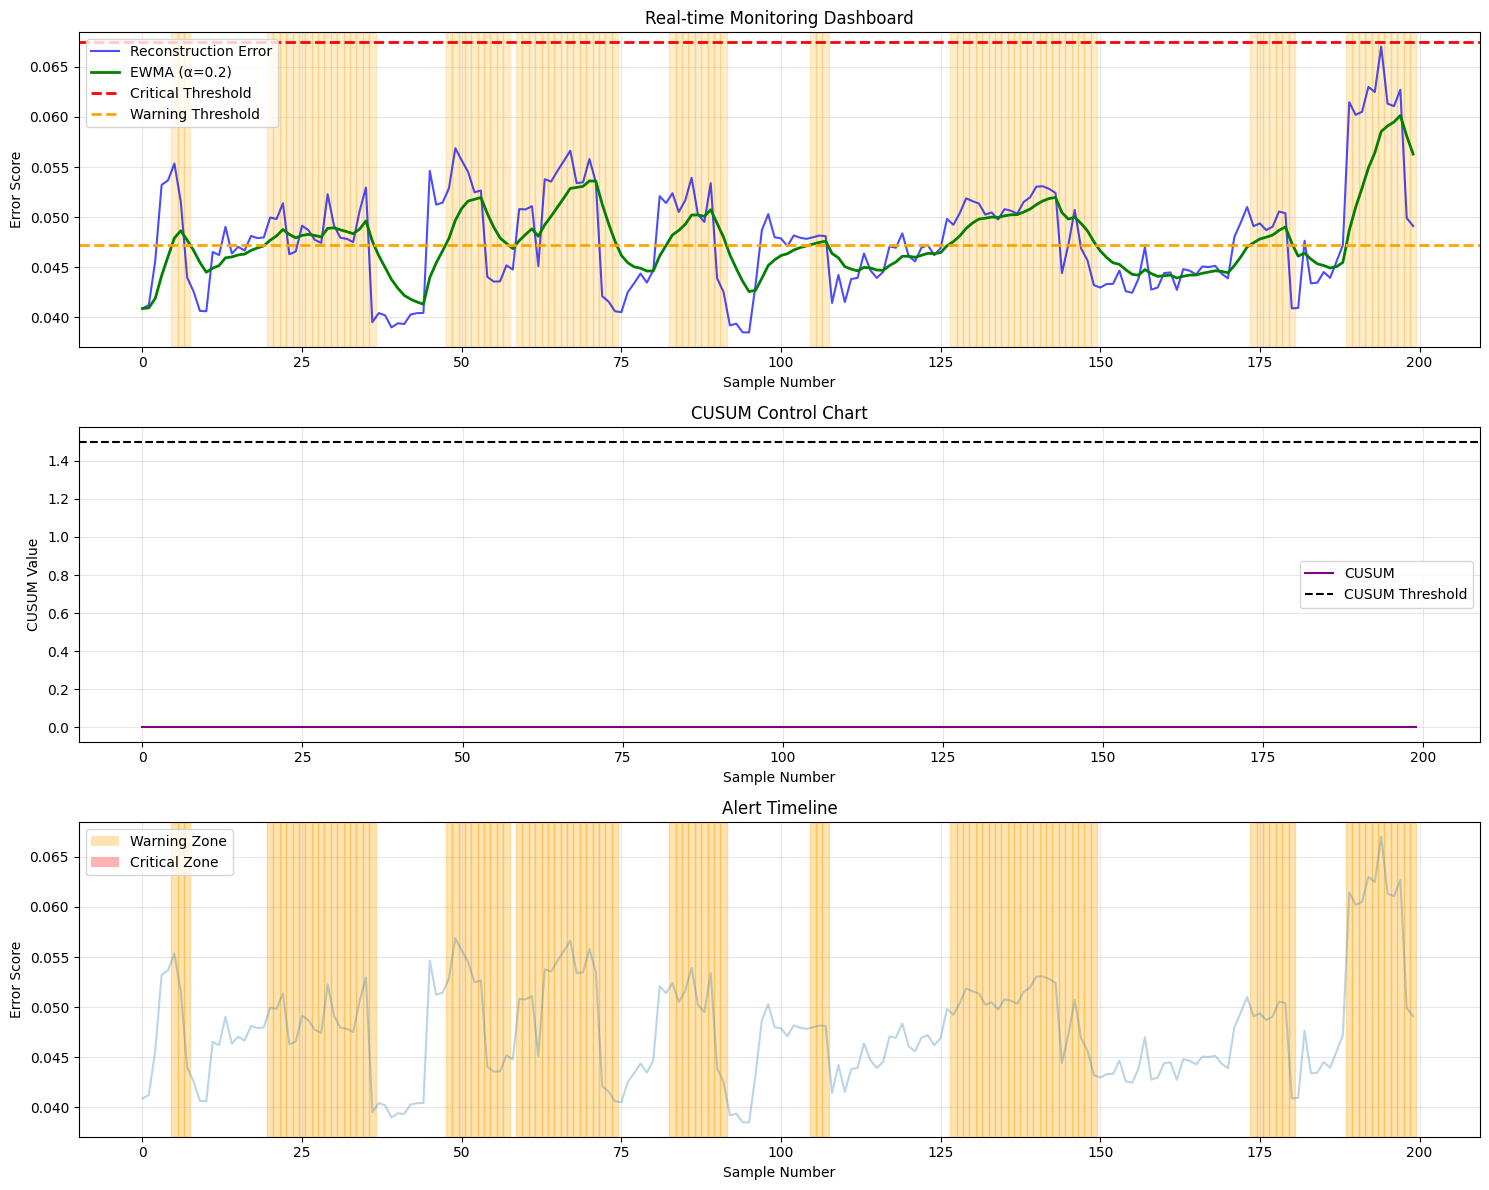

In [16]:
# --- [CELL 15]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 16}
# === BEFORE (original) ===
# # Cell 15: Real-time anomaly detection simulation
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.patches import Patch
# 
# class RealTimeAnomalyDetector:
#     """Simulate real-time anomaly detection"""
#     
#     def __init__(self, autoencoder, threshold, ewma_alpha=0.3, cusum_threshold=2.0):
#         self.autoencoder = autoencoder
#         self.threshold = threshold
#         self.ewma_alpha = ewma_alpha
#         self.cusum_threshold = cusum_threshold
#         
#         # State variables
#         self.scores_history = []
#         self.ewma_history = []
#         self.cusum_history = []
#         self.alerts_history = []
#         self.current_cusum = 0.0
#         
#     def process_sample(self, spectrogram):
#         """Process a single spectrogram sample"""
#         spectrogram = np.asarray(spectrogram, dtype=np.float32)
#         
#         # Ensure correct shape for CNN autoencoder: (1, H, W, 1)
#         if spectrogram.ndim == 2:
#             spectrogram = spectrogram[np.newaxis, ..., np.newaxis]
#         elif spectrogram.ndim == 3:
#             spectrogram = spectrogram[np.newaxis, ...]  # add batch dimension
# 
#         # Get reconstruction
#         reconstruction = self.autoencoder.predict(spectrogram, verbose=0)
#         
#         # Calculate reconstruction error (MSE)
#         error = float(np.mean((spectrogram - reconstruction) ** 2))
#         self.scores_history.append(error)
#         
#         # Calculate EWMA
#         ewma = error if not self.ewma_history else self.ewma_alpha * error + (1 - self.ewma_alpha) * self.ewma_history[-1]
#         self.ewma_history.append(ewma)
#         
#         # Calculate CUSUM
#         self.current_cusum = max(0.0, self.current_cusum + error - 0.1)  # drift
#         self.cusum_history.append(self.current_cusum)
#         
#         # Determine alert level
#         alert_level = 0
#         alert_message = "Normal"
#         
#         if error > self.threshold:
#             alert_level = 2
#             alert_message = "CRITICAL: Anomaly detected!"
#         elif ewma > (self.threshold * 0.7):
#             alert_level = 1
#             alert_message = "WARNING: EWMA early warning"
#         elif self.current_cusum > self.cusum_threshold:
#             alert_level = 1
#             alert_message = "WARNING: CUSUM alert"
#         
#         alert_record = {
#             'sample_idx': len(self.scores_history) - 1,
#             'error': error,
#             'ewma': ewma,
#             'cusum': self.current_cusum,
#             'alert_level': alert_level,
#             'message': alert_message
#         }
#         
#         if alert_level > 0:
#             self.alerts_history.append(alert_record)
#         
#         return alert_record
#     
#     def simulate_realtime(self, X_data, sample_rate=1.0):
#         """Simulate real-time processing"""
#         print(f"Simulating real-time processing of {len(X_data)} samples...")
#         print(f"Sample rate: {sample_rate} Hz")
#         
#         for i, sample in enumerate(X_data):
#             alert = self.process_sample(sample)
#             
#             if alert['alert_level'] > 0:
#                 print(f"\n[{i:04d}] {alert['message']}")
#                 print(f"     Error: {alert['error']:.6f}, EWMA: {alert['ewma']:.6f}, CUSUM: {alert['cusum']:.3f}")
#         
#         print("\nSimulation complete!")
#         print(f"Total alerts: {len(self.alerts_history)}")
#         return self
#     
#     def plot_realtime_monitoring(self):
#         """Plot real-time monitoring results"""
#         if not self.scores_history:
#             print("No data to plot")
#             return
#         
#         fig, axes = plt.subplots(3, 1, figsize=(15, 12))
#         
#         # Plot 1: Errors + EWMA + thresholds
#         axes[0].plot(self.scores_history, 'b-', alpha=0.7, label='Reconstruction Error')
#         axes[0].plot(self.ewma_history, 'g-', linewidth=2, label=f'EWMA (α={self.ewma_alpha})')
#         axes[0].axhline(self.threshold, color='r', linestyle='--', linewidth=2, label='Critical Threshold')
#         axes[0].axhline(self.threshold * 0.7, color='orange', linestyle='--', linewidth=2, label='Warning Threshold')
# 
#         # Highlight alerts
#         for alert in self.alerts_history:
#             color = 'red' if alert['alert_level'] == 2 else 'orange'
#             axes[0].axvspan(alert['sample_idx']-0.5, alert['sample_idx']+0.5, color=color, alpha=0.2)
# 
#         axes[0].set_title('Real-time Monitoring Dashboard')
#         axes[0].set_xlabel('Sample Number')
#         axes[0].set_ylabel('Error Score')
#         axes[0].legend()
#         axes[0].grid(True, alpha=0.3)
#         
#         # Plot 2: CUSUM
#         axes[1].plot(self.cusum_history, 'purple-', label='CUSUM')
#         axes[1].axhline(self.cusum_threshold, linestyle='--', color='k', label='CUSUM Threshold')
#         axes[1].set_title('CUSUM Control Chart')
#         axes[1].set_xlabel('Sample Number')
#         axes[1].set_ylabel('CUSUM Value')
#         axes[1].legend()
#         axes[1].grid(True, alpha=0.3)
#         
#         # Plot 3: Alert timeline
#         axes[2].plot(self.scores_history, alpha=0.3)
#         for alert in self.alerts_history:
#             color = 'red' if alert['alert_level'] == 2 else 'orange'
#             axes[2].axvspan(alert['sample_idx']-0.5, alert['sample_idx']+0.5, color=color, alpha=0.3)
#         
#         axes[2].set_title('Alert Timeline')
#         axes[2].set_xlabel('Sample Number')
#         axes[2].set_ylabel('Error Score')
#         axes[2].grid(True, alpha=0.3)
#         
#         legend_elements = [
#             Patch(facecolor='orange', alpha=0.3, label='Warning Zone'),
#             Patch(facecolor='red', alpha=0.3, label='Critical Zone')
#         ]
#         axes[2].legend(handles=legend_elements)
#         
#         plt.tight_layout()
#         plt.show()
# 
# 
# # ----------------------------
# # Run the real-time simulation
# # ----------------------------
# print("Starting real-time simulation...")
# realtime_detector = RealTimeAnomalyDetector(
#     autoencoder=autoencoder,
#     threshold=anomaly_threshold,
#     ewma_alpha=0.2,
#     cusum_threshold=1.5
# )
# 
# # Process first 200 samples from X_test
# realtime_detector.simulate_realtime(X_test[:200], sample_rate=0.5)
# realtime_detector.plot_realtime_monitoring()

# === AFTER (edited) ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

class RealTimeAnomalyDetector:
    """Simulate real-time anomaly detection"""

    def __init__(self, autoencoder, threshold, ewma_alpha=0.3, cusum_threshold=2.0):
        self.autoencoder = autoencoder
        self.threshold = threshold
        self.ewma_alpha = ewma_alpha
        self.cusum_threshold = cusum_threshold


        self.scores_history = []
        self.ewma_history = []
        self.cusum_history = []
        self.alerts_history = []
        self.current_cusum = 0.0

    def process_sample(self, spectrogram):
        """Process a single spectrogram sample"""
        spectrogram = np.asarray(spectrogram, dtype=np.float32)


        if spectrogram.ndim == 2:
            spectrogram = spectrogram[np.newaxis, ..., np.newaxis]
        elif spectrogram.ndim == 3:
            spectrogram = spectrogram[np.newaxis, ...]


        reconstruction = self.autoencoder.predict(spectrogram, verbose=0)


        error = float(np.mean((spectrogram - reconstruction) ** 2))
        self.scores_history.append(error)


        ewma = error if not self.ewma_history else self.ewma_alpha * error + (1 - self.ewma_alpha) * self.ewma_history[-1]
        self.ewma_history.append(ewma)


        self.current_cusum = max(0.0, self.current_cusum + error - 0.1)
        self.cusum_history.append(self.current_cusum)


        alert_level = 0
        alert_message = "Normal"

        if error > self.threshold:
            alert_level = 2
            alert_message = "CRITICAL: Anomaly detected!"
        elif ewma > (self.threshold * 0.7):
            alert_level = 1
            alert_message = "WARNING: EWMA early warning"
        elif self.current_cusum > self.cusum_threshold:
            alert_level = 1
            alert_message = "WARNING: CUSUM alert"

        alert_record = {
            'sample_idx': len(self.scores_history) - 1,
            'error': error,
            'ewma': ewma,
            'cusum': self.current_cusum,
            'alert_level': alert_level,
            'message': alert_message
        }

        if alert_level > 0:
            self.alerts_history.append(alert_record)

        return alert_record

    def simulate_realtime(self, X_data, sample_rate=1.0):
        """Simulate real-time processing"""
        print(f"Simulating real-time processing of {len(X_data)} samples...")
        print(f"Sample rate: {sample_rate} Hz")

        for i, sample in enumerate(X_data):
            alert = self.process_sample(sample)

            if alert['alert_level'] > 0:
                print(f"\n[{i:04d}] {alert['message']}")
                print(f"     Error: {alert['error']:.6f}, EWMA: {alert['ewma']:.6f}, CUSUM: {alert['cusum']:.3f}")

        print("\nSimulation complete!")
        print(f"Total alerts: {len(self.alerts_history)}")
        return self

    def plot_realtime_monitoring(self):
        """Plot real-time monitoring results"""
        if not self.scores_history:
            print("No data to plot")
            return

        fig, axes = plt.subplots(3, 1, figsize=(15, 12))


        axes[0].plot(self.scores_history, 'b-', alpha=0.7, label='Reconstruction Error')
        axes[0].plot(self.ewma_history, 'g-', linewidth=2, label=f'EWMA (α={self.ewma_alpha})')
        axes[0].axhline(self.threshold, color='r', linestyle='--', linewidth=2, label='Critical Threshold')
        axes[0].axhline(self.threshold * 0.7, color='orange', linestyle='--', linewidth=2, label='Warning Threshold')


        for alert in self.alerts_history:
            color = 'red' if alert['alert_level'] == 2 else 'orange'
            axes[0].axvspan(alert['sample_idx']-0.5, alert['sample_idx']+0.5, color=color, alpha=0.2)

        axes[0].set_title('Real-time Monitoring Dashboard')
        axes[0].set_xlabel('Sample Number')
        axes[0].set_ylabel('Error Score')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)


        axes[1].plot(self.cusum_history, color='purple', linestyle='-', label='CUSUM')
        axes[1].axhline(self.cusum_threshold, linestyle='--', color='k', label='CUSUM Threshold')
        axes[1].set_title('CUSUM Control Chart')
        axes[1].set_xlabel('Sample Number')
        axes[1].set_ylabel('CUSUM Value')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)


        axes[2].plot(self.scores_history, alpha=0.3)
        for alert in self.alerts_history:
            color = 'red' if alert['alert_level'] == 2 else 'orange'
            axes[2].axvspan(alert['sample_idx']-0.5, alert['sample_idx']+0.5, color=color, alpha=0.3)

        axes[2].set_title('Alert Timeline')
        axes[2].set_xlabel('Sample Number')
        axes[2].set_ylabel('Error Score')
        axes[2].grid(True, alpha=0.3)

        legend_elements = [
            Patch(facecolor='orange', alpha=0.3, label='Warning Zone'),
            Patch(facecolor='red', alpha=0.3, label='Critical Zone')
        ]
        axes[2].legend(handles=legend_elements)

        plt.tight_layout()
        plt.show()





print("Starting real-time simulation...")
realtime_detector = RealTimeAnomalyDetector(
    autoencoder=autoencoder,
    threshold=anomaly_threshold,
    ewma_alpha=0.2,
    cusum_threshold=1.5
)


realtime_detector.simulate_realtime(X_test[:200], sample_rate=0.5)
realtime_detector.plot_realtime_monitoring()

In [17]:
# Test: CUSUM plotting uses a valid matplotlib line spec and renders expected line data
import numpy as np
import matplotlib.pyplot as plt

class _IdentityAutoencoder:
    def predict(self, x, verbose=0):
        return x

# Build a small detector instance independent of previous cell plot state
det = RealTimeAnomalyDetector(
    autoencoder=_IdentityAutoencoder(),
    threshold=0.05,
    ewma_alpha=0.2,
    cusum_threshold=0.2,
)

# Feed deterministic samples with increasing magnitudes so CUSUM evolves
samples = [
    np.full((8, 8), 0.00, dtype=np.float32),
    np.full((8, 8), 0.05, dtype=np.float32),
    np.full((8, 8), 0.10, dtype=np.float32),
    np.full((8, 8), 0.20, dtype=np.float32),
]
for s in samples:
    det.process_sample(s)

captured = {}
_orig_show = plt.show

def _capture_show(*args, **kwargs):
    captured['fig'] = plt.gcf()

plt.show = _capture_show
try:
    det.plot_realtime_monitoring()
finally:
    plt.show = _orig_show

assert 'fig' in captured, "Expected plot_realtime_monitoring() to call plt.show() with a figure"
fig = captured['fig']
assert len(fig.axes) == 3, f"Expected 3 subplots, found {len(fig.axes)}"

cusum_ax = fig.axes[1]
cusum_lines = [ln for ln in cusum_ax.lines if ln.get_label() == 'CUSUM']
assert cusum_lines, "Expected a CUSUM line on the second subplot"

cusum_line = cusum_lines[0]
assert cusum_line.get_color() == 'purple', f"Expected CUSUM line color purple, got {cusum_line.get_color()}"
assert cusum_line.get_linestyle() == '-', f"Expected solid CUSUM line, got {cusum_line.get_linestyle()}"
assert np.allclose(cusum_line.get_ydata(), det.cusum_history), "CUSUM line data must match detector cusum_history"

plt.close(fig)